# What is Molecular Alignment?
Molecular alignment is the process of placing two or more molecules in the same coordinate system so that their common structural features overlap as closely as possible.
In simple words,
Alignment means superimposing molecules to compare their shapes and atom positions.

# Types of Alignment 

# How does RDKit perform alignment?
RDKit first finds corresponding atoms (or uses a common scaffold), then:
Translates the molecules.
Rotates them.
Minimizes the distance between matching atoms.
The quality of the alignment is measured by RMSD (Root Mean Square Deviation).

# RMSD 
Average distance between corresponding atoms. 

Perfect overlap: RMSD ≈ 0

Small difference:  RMSD = small

Large difference: RMSD = large

# RDKit functions we'll learn
AllChem.AlignMol()

AllChem.GetBestRMS()

rdMolAlign.AlignMol()

rdMolAlign.GetBestRMS()

# Example

In [1]:
# Import Libraries 

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolAlign
import py3Dmol

In [2]:
# Create the Molecules ibuprofen and flurbiprofen

ibuprofen_smiles = "CC(C)Cc1ccc(cc1)[C@@H](C)C(=O)O"

flurbiprofen_smiles = "CC(C)c1ccc(cc1[C@H](C)C(=O)O)c2ccccc2F"

ibuprofen = Chem.MolFromSmiles(ibuprofen_smiles)
flurbiprofen = Chem.MolFromSmiles(flurbiprofen_smiles)



In [3]:
# Add explicit hydrogen

ibuprofen = Chem.AddHs(ibuprofen)
flurbiprofen = Chem.AddHs(flurbiprofen)

In [4]:
# Generate 3D conformer

AllChem.EmbedMolecule(ibuprofen)

AllChem.EmbedMolecule(flurbiprofen)

0

In [5]:
# Optimize Geometry

AllChem.MMFFOptimizeMolecule(ibuprofen)

AllChem.MMFFOptimizeMolecule(flurbiprofen)

0

In [7]:
# Convert molecules into MOL blocks

ibuprofen_block = Chem.MolToMolBlock(ibuprofen)

flurbiprofen_block = Chem.MolToMolBlock(flurbiprofen)

In [8]:
# Visualize

view = py3Dmol.view(width=700, height=450)

view.addModel(ibuprofen_block,"mol")
view.setStyle({"model":0},{"stick":{"colorscheme":"greenCarbon"}})

view.addModel(flurbiprofen_block,"mol")
view.setStyle({"model":1},{"stick":{"colorscheme":"cyanCarbon"}})

view.zoomTo()

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The two molecules are displayed in their independently generated 3D conformations. Since no alignment has been performed, they occupy different positions and orientations in space. Although Ibuprofen and Flurbiprofen share a similar chemical scaffold, their common structural features do not overlap, making direct comparison difficult.

In [10]:
# Find the maximum common substructure (MCS)

from rdkit.Chem import rdFMCS

mcs = rdFMCS.FindMCS([ibuprofen, flurbiprofen])

print(mcs.smartsString)

[#6](-[#6](-[#6](-[#1])(-[#1])-[#1])(-[#6]-,:[#6](:[#6](:[#6]:,-[#6]-,:[#6](-,:[#6]-[#1])-[#1])-[#1]):,-[#6](:,-[#6]-[#1])-[#1])-[#1])(-[#1])(-[#1])-[#1]


RDKit searches both molecules and identifies the largest substructure that exists in both. This common scaffold will be used for alignment.

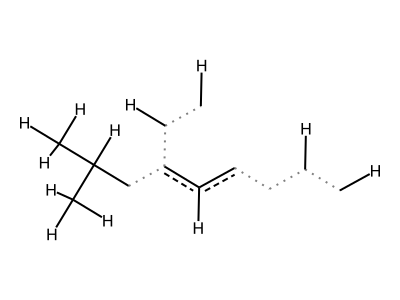

In [12]:
# Create the common Core
from rdkit.Chem import Draw
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

Draw.MolToImage(mcs_mol, size=(400,300))

In [13]:
# Find Matching Atoms

ibuprofen_match = ibuprofen.GetSubstructMatch(mcs_mol)

flurbiprofen_match = flurbiprofen.GetSubstructMatch(mcs_mol)

print(ibuprofen_match)
print(flurbiprofen_match)

(0, 1, 2, 19, 20, 21, 3, 4, 5, 6, 7, 10, 11, 29, 28, 24, 9, 8, 26, 27, 18, 15, 16, 17)
(0, 1, 2, 25, 26, 27, 3, 8, 7, 6, 14, 15, 16, 37, 36, 30, 9, 10, 32, 31, 24, 21, 22, 23)


RDKit returns the atom indices corresponding to the common scaffold in each molecule.

In [14]:
# Create the atom Map

atom_map = list(zip(flurbiprofen_match, ibuprofen_match))

print(atom_map)

[(0, 0), (1, 1), (2, 2), (25, 19), (26, 20), (27, 21), (3, 3), (8, 4), (7, 5), (6, 6), (14, 7), (15, 10), (16, 11), (37, 29), (36, 28), (30, 24), (9, 9), (10, 8), (32, 26), (31, 27), (24, 18), (21, 15), (22, 16), (23, 17)]


Each tuple tells RDKit:
"This atom in Flurbiprofen corresponds to this atom in Ibuprofen."

In [15]:
# Align using the atom map

rmsd = rdMolAlign.AlignMol(
    flurbiprofen,
    ibuprofen,
    atomMap=atom_map
)

print(f"RMSD = {rmsd:.3f} Å")

RMSD = 2.355 Å


In [16]:
# Visualize

# Convert aligned molecules to MOL blocks
ibuprofen_block = Chem.MolToMolBlock(ibuprofen)
flurbiprofen_block = Chem.MolToMolBlock(flurbiprofen)

# Create viewer
view = py3Dmol.view(width=700, height=500)

# Reference molecule (Ibuprofen) - Green
view.addModel(ibuprofen_block, "mol")
view.setStyle(
    {"model": 0},
    {"stick": {"colorscheme": "greenCarbon"}}
)

# Aligned molecule (Flurbiprofen) - Cyan
view.addModel(flurbiprofen_block, "mol")
view.setStyle(
    {"model": 1},
    {"stick": {"colorscheme": "cyanCarbon"}}
)

# Center and zoom
view.zoomTo()

# White background
view.setBackgroundColor("white")

view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Interpretation

After identifying the Maximum Common Substructure (MCS), an atom map was created to align Flurbiprofen onto Ibuprofen. The calculated RMSD was 2.355 Å, indicating a moderate structural overlap.

The common arylpropionic acid scaffold aligns reasonably well, demonstrating that both molecules share a similar core framework. However, Flurbiprofen contains an additional fluorophenyl ring that is absent in Ibuprofen. This extra aromatic ring extends away from the common scaffold, resulting in a higher RMSD and an imperfect overlap.

This example demonstrates how molecular alignment can reveal both shared structural features and regions of structural diversity, making it a valuable tool in medicinal chemistry, scaffold comparison, and structure-based drug design.

In [17]:
view.setStyle(
    {"model": 0},
    {"stick": {"colorscheme": "greenCarbon", "opacity": 0.5}}
)

view.setStyle(
    {"model": 1},
    {"stick": {"colorscheme": "cyanCarbon"}}
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.